File version: 1.1

In [1]:
import sys;

print('Python %s on %s' % (sys.version, sys.platform))
sys.path.extend(['../'])

Python 3.12.3 (tags/v3.12.3:f6650f9, Apr  9 2024, 14:05:25) [MSC v.1938 64 bit (AMD64)] on win32


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scripts.data_utils import get_connectome

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

In [3]:
# load both files with series

bnu_series_path = '../data/ts_cut/HCPex/bnu{}.npy'
bnu_labels_path = '../data/ts_cut/HCPex/bnu.csv'
ihb_series_path = '../data/ts_cut/HCPex/ihb.npy'
ihb_labels_path = '../data/ts_cut/HCPex/ihb.csv'

X_bnu = np.concatenate([np.load(bnu_series_path.format(i)) for i in (1, 2)], axis=0)
Y_bnu = pd.read_csv(bnu_labels_path)
X_ihb = np.load(ihb_series_path)
Y_ihb = pd.read_csv(ihb_labels_path)

X_bnu = get_connectome(X_bnu)
X_ihb = get_connectome(X_ihb)

X = np.concatenate([X_bnu, X_ihb])
Y = np.concatenate([Y_bnu, Y_ihb])

X.shape, Y.shape

((162, 419, 419), (162, 1))

In [4]:
# import numpy as np
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import matplotlib.pyplot as plt
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score, f1_score

# # Пример данных
# n_samples = X.shape[0]
# X_reshaped = X.reshape(n_samples, -1).astype('float32')
# Y = Y.astype('float32')


# X_train, X_val, Y_train, Y_val = train_test_split(X_reshaped, Y, test_size=0.35)

# # Модель с одним линейным слоем
# class SimpleModel(nn.Module):
#     def __init__(self, input_size):
#         super(SimpleModel, self).__init__()
#         self.linear = nn.Linear(input_size, 1)

#     def forward(self, x):
#         return torch.sigmoid(self.linear(x))

# # Преобразование данных в тензоры
# X_train_tensor = torch.tensor(X_train)
# Y_train_tensor = torch.tensor(Y_train).view(-1, 1)
# X_val_tensor = torch.tensor(X_val)
# Y_val_tensor = torch.tensor(Y_val).view(-1, 1)

# # Создание модели
# model = SimpleModel(X_train_tensor.shape[1])

# # Определение функции потерь и оптимизатора
# criterion = nn.BCELoss()  # Для бинарной классификации
# optimizer = optim.Adam(model.parameters(), lr=0.0003, weight_decay=0.001)

# # Списки для хранения метрик
# train_losses = []
# val_losses = []
# accuracies = []
# f1_scores = []

# # Ранняя остановка
# best_accuracy = float('-inf')
# patience = 15
# patience_counter = 0
# best_model_weights = None

# # Обучение модели
# num_epochs = 100  # Задайте количество эпох
# for epoch in range(num_epochs):
#     model.train()  # Переключение в режим обучения

#     optimizer.zero_grad()  # Обнуление градиентов
#     outputs = model(X_train_tensor)  # Прямой проход
#     loss = criterion(outputs, Y_train_tensor)  # Вычисление потерь
#     loss.backward()  # Обратный проход
#     optimizer.step()  # Обновление параметров

#     train_losses.append(loss.item())

#     # Валидация
#     model.eval()  # Переключение в режим оценки
#     with torch.no_grad():
#         val_outputs = model(X_val_tensor)
#         val_loss = criterion(val_outputs, Y_val_tensor)
#         val_losses.append(val_loss.item())

#         # Применение порога
#         val_predictions = (val_outputs.view(-1) >= 0.5).float()  # Применение порога для бинарной классификации
#         accuracy = accuracy_score(Y_val, val_predictions.cpu().numpy())
#         f1 = f1_score(Y_val, val_predictions.cpu().numpy())
#         accuracies.append(accuracy)
#         f1_scores.append(f1)

#     # Проверка на раннюю остановку
#     if accuracy > best_accuracy:
#         best_accuracy = accuracy
#         best_model_weights = model.state_dict()
#         patience_counter = 0
#     else:
#         patience_counter += 1

#     if patience_counter >= patience:
#         print(f'Early stopping at epoch {epoch + 1}')
#         break

#     print(f'Epoch [{epoch + 1}/{num_epochs}], Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}, Accuracy: {accuracy:.2f}, F1 Score: {f1:.2f}')

# # Загрузка лучших весов
# model.load_state_dict(best_model_weights)
# model.eval()  # Переключение в режим оценки
# with torch.no_grad():
#     val_outputs = model(X_val_tensor)
#     val_loss = criterion(val_outputs, Y_val_tensor)
# val_losses.append(val_loss.item())


# val_predictions = (val_outputs.view(-1) >= 0.5).float()
# print(accuracy_score(Y_val, val_predictions.cpu().numpy()))
# print(f1_score(Y_val, val_predictions.cpu().numpy()))


# plt.figure(figsize=(12, 8))


# plt.subplot(2, 2, 1)
# plt.plot(train_losses, label='Train Loss', color='blue')
# plt.plot(val_losses, label='Validation Loss', color='orange')
# plt.xlabel('Epochs')
# plt.ylabel('Loss')
# plt.title('Train and Validation Loss')
# plt.legend()

# # Accuracy
# plt.subplot(2, 2, 2)
# plt.plot(accuracies, label='Accuracy', color='green')
# plt.xlabel('Epochs')
# plt.ylabel('Accuracy')
# plt.title('Validation Accuracy')
# plt.legend()

# # F1 Score
# plt.subplot(2, 2, 3)
# plt.plot(f1_scores, label='F1 Score', color='red')
# plt.xlabel('Epochs')
# plt.ylabel('F1 Score')
# plt.title('Validation F1 Score')
# plt.legend()

# plt.tight_layout()
# plt.show()


Epoch [1/100], Train Loss: 0.7006, Val Loss: 1.1363, Accuracy: 0.58, F1 Score: 0.00
Epoch [2/100], Train Loss: 0.8489, Val Loss: 0.8111, Accuracy: 0.58, F1 Score: 0.00
Epoch [3/100], Train Loss: 0.5494, Val Loss: 0.4726, Accuracy: 0.79, F1 Score: 0.67
Epoch [4/100], Train Loss: 0.3052, Val Loss: 0.4815, Accuracy: 0.81, F1 Score: 0.81
Epoch [5/100], Train Loss: 0.3512, Val Loss: 0.4659, Accuracy: 0.81, F1 Score: 0.81
Epoch [6/100], Train Loss: 0.3153, Val Loss: 0.3752, Accuracy: 0.84, F1 Score: 0.82
Epoch [7/100], Train Loss: 0.2011, Val Loss: 0.3346, Accuracy: 0.88, F1 Score: 0.83
Epoch [8/100], Train Loss: 0.1330, Val Loss: 0.3646, Accuracy: 0.82, F1 Score: 0.74
Epoch [9/100], Train Loss: 0.1171, Val Loss: 0.4170, Accuracy: 0.79, F1 Score: 0.67
Epoch [10/100], Train Loss: 0.1187, Val Loss: 0.4491, Accuracy: 0.79, F1 Score: 0.67
Epoch [11/100], Train Loss: 0.1146, Val Loss: 0.4466, Accuracy: 0.79, F1 Score: 0.67
Epoch [12/100], Train Loss: 0.0989, Val Loss: 0.4169, Accuracy: 0.79, F1 S

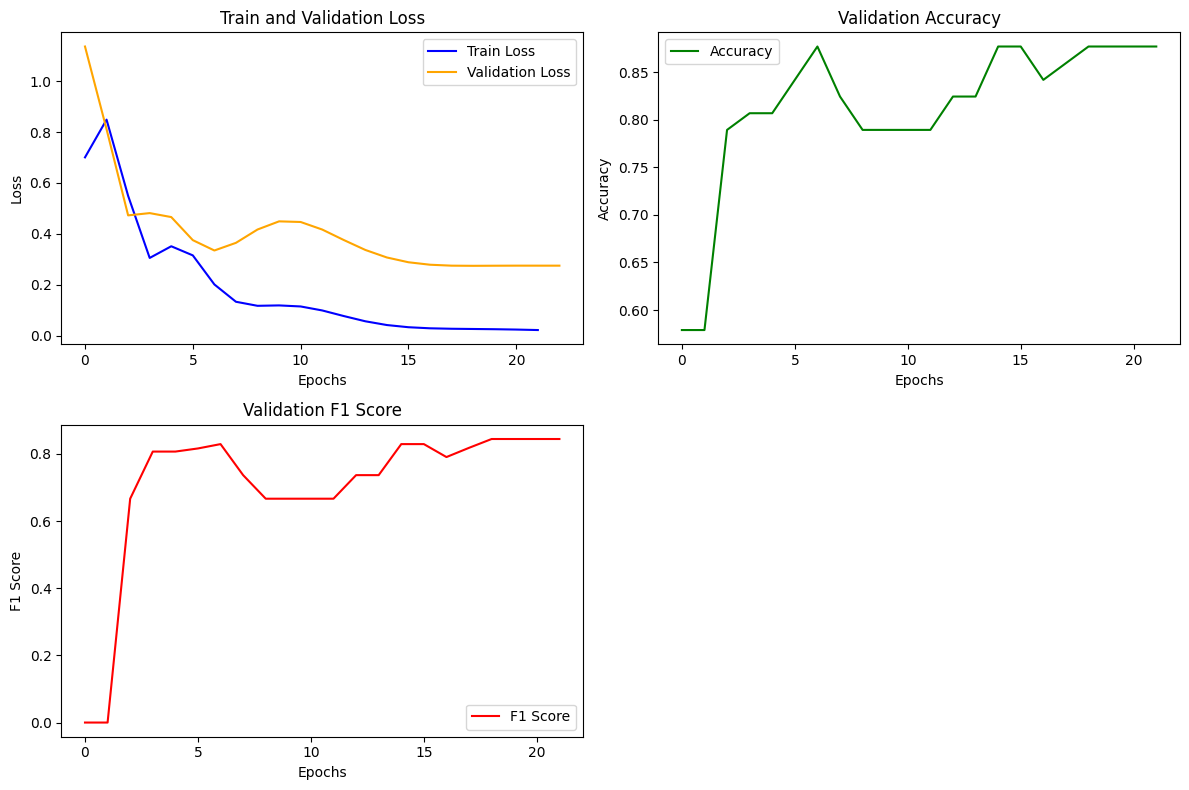

In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

# Проверьте, доступен ли GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Пример данных
n_samples = X.shape[0]
X_reshaped = X.reshape(n_samples, -1).astype('float32')
Y = Y.astype('float32')

X_train, X_val, Y_train, Y_val = train_test_split(X_reshaped, Y, test_size=0.35)

# Модель с одним линейным слоем
class SimpleModel(nn.Module):
    def __init__(self, input_size):
        super(SimpleModel, self).__init__()
        self.linear = nn.Linear(input_size, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))

# Преобразование данных в тензоры и перемещение на устройство (GPU или CPU)
X_train_tensor = torch.tensor(X_train).to(device)
Y_train_tensor = torch.tensor(Y_train).view(-1, 1).to(device)
X_val_tensor = torch.tensor(X_val).to(device)
Y_val_tensor = torch.tensor(Y_val).view(-1, 1).to(device)

# Создание модели и перемещение на устройство
model = SimpleModel(X_train_tensor.shape[1]).to(device)

# Определение функции потерь и оптимизатора
criterion = nn.BCELoss()  # Для бинарной классификации
optimizer = optim.Adam(model.parameters(), lr=0.0003, weight_decay=0.001)

# Списки для хранения метрик
train_losses = []
val_losses = []
accuracies = []
f1_scores = []

# Ранняя остановка
best_accuracy = float('-inf')
patience = 15
patience_counter = 0
best_model_weights = None

# Обучение модели
num_epochs = 100  # Задайте количество эпох
for epoch in range(num_epochs):
    model.train()  # Переключение в режим обучения

    optimizer.zero_grad()  # Обнуление градиентов
    outputs = model(X_train_tensor)  # Прямой проход
    loss = criterion(outputs, Y_train_tensor)  # Вычисление потерь
    loss.backward()  # Обратный проход
    optimizer.step()  # Обновление параметров

    train_losses.append(loss.item())

    # Валидация
    model.eval()  # Переключение в режим оценки
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = criterion(val_outputs, Y_val_tensor)
        val_losses.append(val_loss.item())

        # Применение порога
        val_predictions = (val_outputs.view(-1) >= 0.5).float()  # Применение порога для бинарной классификации
        accuracy = accuracy_score(Y_val, val_predictions.cpu().numpy())
        f1 = f1_score(Y_val, val_predictions.cpu().numpy())
        accuracies.append(accuracy)
        f1_scores.append(f1)

    # Проверка на раннюю остановку
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model_weights = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f'Early stopping at epoch {epoch + 1}')
        break

    print(f'Epoch [{epoch + 1}/{num_epochs}], Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}, Accuracy: {accuracy:.2f}, F1 Score: {f1:.2f}')

# Загрузка лучших весов
model.load_state_dict(best_model_weights)
model.eval()  # Переключение в режим оценки
with torch.no_grad():
    val_outputs = model(X_val_tensor)
    val_loss = criterion(val_outputs, Y_val_tensor)
val_losses.append(val_loss.item())

val_predictions = (val_outputs.view(-1) >= 0.5).float()
print(accuracy_score(Y_val, val_predictions.cpu().numpy()))
print(f1_score(Y_val, val_predictions.cpu().numpy()))

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train and Validation Loss')
plt.legend()

# Accuracy
plt.subplot(2, 2, 2)
plt.plot(accuracies, label='Accuracy', color='green')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.legend()

# F1 Score
plt.subplot(2, 2, 3)
plt.plot(f1_scores, label='F1 Score', color='red')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('Validation F1 Score')
plt.legend()

plt.tight_layout()
plt.show()
exit(0)

In [6]:
import pickle


with open('model.pkl', 'wb') as file:
    pickle.dump(model, file)

In [1]:
# create local environment same as Yandex Contest
import os
import shutil

if not os.path.exists('./data/ts_cut/HCPex/'):
    os.makedirs('./data/ts_cut/HCPex/')

np.save('./data/ts_cut/HCPex/predict.npy', np.concatenate([np.load(bnu_series_path.format(i)) for i in (1, 2)], axis=0))


NameError: name 'np' is not defined

In [ ]:
import numpy as np
import pandas as pd
import pickle

from scripts.data_utils import get_connectome
import torch
import torch.nn as nn


class SimpleModel(nn.Module):
    def __init__(self, input_size):
        super(SimpleModel, self).__init__()
        self.linear = nn.Linear(input_size, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))


X = np.load('./data/ts_cut/HCPex/predict.npy')
# print(X.shape)
X = get_connectome(X)

with open('model.pkl', 'rb') as file:
    model = pickle.load(file)

n_samples = X.shape[0]
X_reshaped = X.reshape(n_samples, -1).astype('float32')
X_tensor = torch.tensor(X_reshaped)

model.eval()
with torch.no_grad():
    y_pred = model(X_tensor)
    y_pred_binary = (y_pred.view(-1) >= 0.5).float()
y_pred = y_pred_binary.numpy()

solution = pd.DataFrame(data=y_pred, columns=['prediction'])
solution.to_csv('./solution.csv', index=False)

print(X.shape)
print(y_pred)
print(type(y_pred))

In [59]:
# build the .zip to submit
import zipfile
import datetime

# save source from previous cell into file
# will produce the correct result only in case of running previous cell just before
with open('run.py', 'w') as f_run:
    f_run.write(_ih[-2])

with open('run.sh', 'w') as f_run_sh:
    f_run_sh.write('export PATH=/usr/conda/bin:$PATH\npython run.py')

with open('train.py', 'w') as f_run:
    f_run.write('print("\\n".join(map(str, range(100))))')

with open('train.sh', 'w') as f_run_sh:
    f_run_sh.write('export PATH=/usr/conda/bin:$PATH\npython train.py')

with open('Makefile', 'w') as f_makefile:
    f_makefile.write('''all: build

build:
	@echo 'starting....'
	bash train.sh
run:
	bash run.sh
train:
	bash train.sh
''')

submission_zip = zipfile.ZipFile(f"submission-{datetime.datetime.now()}.zip".replace(':', '-').replace(' ', '-'), "w")
submission_zip.write('./Makefile', compress_type=zipfile.ZIP_DEFLATED)
submission_zip.write('run.py', compress_type=zipfile.ZIP_DEFLATED)
submission_zip.write('run.sh', compress_type=zipfile.ZIP_DEFLATED)
submission_zip.write('train.py', compress_type=zipfile.ZIP_DEFLATED)
submission_zip.write('train.sh', compress_type=zipfile.ZIP_DEFLATED)
submission_zip.write('model.pkl', compress_type=zipfile.ZIP_DEFLATED)
submission_zip.write('scripts', compress_type=zipfile.ZIP_DEFLATED)
submission_zip.write('scripts/__init__.py', compress_type=zipfile.ZIP_DEFLATED)
submission_zip.write('scripts/classification_models.py', compress_type=zipfile.ZIP_DEFLATED)
submission_zip.write('scripts/data_utils.py', compress_type=zipfile.ZIP_DEFLATED)

submission_zip.close()
